# 🧠 Study Session 6 — Model Robustness & Assumption Checks
**Goal:** make sure our linear models are *trustworthy* before interpreting coefficients.

### 🔍 Part 1 — OLS Assumptions Refresher
Ordinary Least Squares (OLS) regression relies on several key assumptions.  
Violations can bias estimates or inflate uncertainty.

| Assumption | What It Means | What to Check |
|-------------|---------------|---------------|
| Linearity | Relationship between predictors and outcome is roughly linear | Scatter plots of y vs each x |
| Independence | Errors are independent (observations not linked) | Study design / Durbin–Watson |
| Homoscedasticity | Equal error variance across predictions | Residuals vs Predicted plot |
| Normality of errors | Residuals are normally distributed | Histogram + Q–Q plot |
| No multicollinearity | Predictors not highly correlated | Variance Inflation Factor (VIF) |

We’ll demonstrate each diagnostic visually and numerically.


In [1]:
# --- 1. Import libraries ---
import os
import sys
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Manually define the correct project root path based on your previous output
CORRECT_PROJECT_ROOT = "/home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one"

# Set CWD
try:
    os.chdir(CORRECT_PROJECT_ROOT)
    print(f"✅ CWD successfully set to: {os.getcwd()}")

    # Add to sys.path for module imports (src.helpers)
    if CORRECT_PROJECT_ROOT not in sys.path:
        sys.path.append(CORRECT_PROJECT_ROOT)
        print("✅ Added project root to sys.path.")

except FileNotFoundError:
    print("❌ CRITICAL ERROR: The manually defined project path does not exist.")
    sys.exit(1)

✅ CWD successfully set to: /home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one
✅ Added project root to sys.path.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set(style="whitegrid")

# 1️⃣ Synthetic dataset mimicking restaurant tips
np.random.seed(42)
n = 250
bill_total_usd = np.random.uniform(10, 70, n)
party_size = np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.2, 0.4, 0.25, 0.1, 0.05])
noise = np.random.normal(0, 1, n)

# Simulate a slightly heteroscedastic pattern
tip_usd = 0.1 * bill_total_usd + 0.2 * party_size + noise * (bill_total_usd / 40)

df = pd.DataFrame({
    "bill_total_usd": bill_total_usd,
    "party_size": party_size,
    "tip_usd": tip_usd
})

df.head()


,bill_total_usd,party_size,tip_usd
0,32.472407,2,3.924682
1,67.042858,2,10.248882
2,53.919637,4,7.473126
3,45.919509,2,4.329673
4,19.361118,1,1.701254


In [2]:
X = sm.add_constant(df[["bill_total_usd", "party_size"]])
y = df["tip_usd"]

model = sm.OLS(y, X).fit()
df["predicted"] = model.fittedvalues
df["residuals"] = model.resid

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                tip_usd   R-squared:                       0.713
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     307.0
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           1.06e-67
Time:                        17:36:16   Log-Likelihood:                -398.64
No. Observations:                 250   AIC:                             803.3
Df Residuals:                     247   BIC:                             813.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1853      0.239     -0.

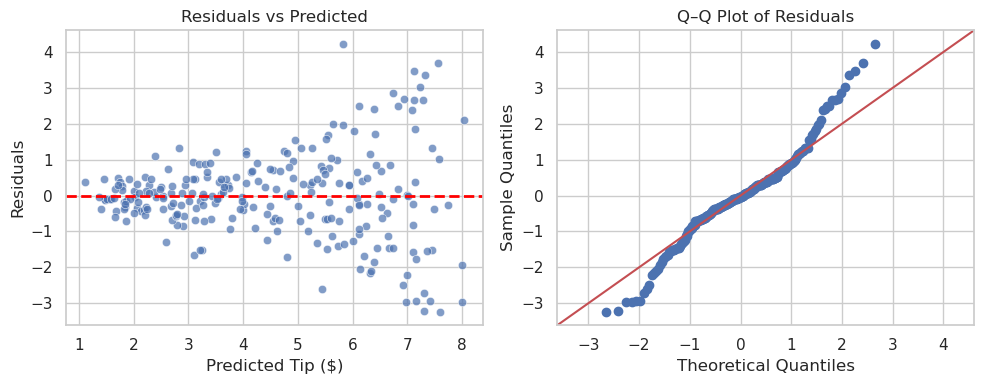

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Residuals vs Predicted
sns.scatterplot(x="predicted", y="residuals", data=df, ax=axes[0], alpha=0.7)
axes[0].axhline(0, color="red", linestyle="--", lw=2)
axes[0].set_title("Residuals vs Predicted")
axes[0].set_xlabel("Predicted Tip ($)")
axes[0].set_ylabel("Residuals")

# Q–Q plot
sm.qqplot(df["residuals"], line="45", ax=axes[1])
axes[1].set_title("Q–Q Plot of Residuals")

plt.tight_layout()
plt.show()


In [4]:
X_no_const = df[["bill_total_usd", "party_size"]]
X_vif = sm.add_constant(X_no_const)

vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).query("Feature != 'const'")

display(vif_data)


,Feature,VIF
1,bill_total_usd,1.002298
2,party_size,1.002298


### ✅ Interpretation
- The **Residuals vs Predicted** plot should look like random scatter around 0.  
  If a funnel shape appears → possible heteroscedasticity.
- The **Q–Q plot** checks residual normality: points should fall near the red line.
- The **VIF** values show multicollinearity:  
  - ≈ 1 = independent (good)  - 5–10 = overlap  > 10 = bad

These diagnostics confirm whether our regression’s assumptions are holding before we move to robust corrections.


In [5]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

# Prepare data
X_const = sm.add_constant(df[["bill_total_usd", "party_size"]])
y = df["tip_usd"]

# Fit OLS model
ols_model = sm.OLS(y, X_const).fit()

# --- Breusch–Pagan test for heteroscedasticity ---
# H0: Constant variance (homoscedastic)
# H1: Non-constant variance (heteroscedastic)
bp_test = sms.het_breuschpagan(ols_model.resid, ols_model.model.exog)
bp_labels = ["Lagrange multiplier", "p-value", "f-value", "f p-value"]

print(lzip(bp_labels, bp_test))

if bp_test[1] < 0.05:
    print("⚠️ Evidence of heteroscedasticity (p < 0.05)")
else:
    print("✅ No strong evidence of heteroscedasticity")


[('Lagrange multiplier', np.float64(69.26959090553613)), ('p-value', np.float64(9.0844670285603e-16)), ('f-value', np.float64(47.33456046327161)), ('f p-value', np.float64(3.960646093116754e-18))]
⚠️ Evidence of heteroscedasticity (p < 0.05)


In [6]:
# Fit OLS again, but use robust SEs (HC3)
robust_model = ols_model.get_robustcov_results(cov_type="HC3")

print(robust_model.summary())

# Compare standard vs robust SEs
compare = pd.DataFrame({
    "Coefficient": ols_model.params,
    "StdErr_OLS": ols_model.bse,
    "StdErr_Robust": robust_model.bse,
    "t_OLS": ols_model.tvalues,
    "t_Robust": robust_model.tvalues
})
compare.round(4)


                            OLS Regression Results                            
Dep. Variable:                tip_usd   R-squared:                       0.713
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     207.8
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           1.20e-53
Time:                        17:48:17   Log-Likelihood:                -398.64
No. Observations:                 250   AIC:                             803.3
Df Residuals:                     247   BIC:                             813.8
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1853      0.252     -0.

,Coefficient,StdErr_OLS,StdErr_Robust,t_OLS,t_Robust
const,-0.1853,0.2391,0.2517,-0.7751,-0.7361
bill_total_usd,0.1038,0.0043,0.0051,24.3406,20.3837
party_size,0.2288,0.0660,0.0791,3.4687,2.8928


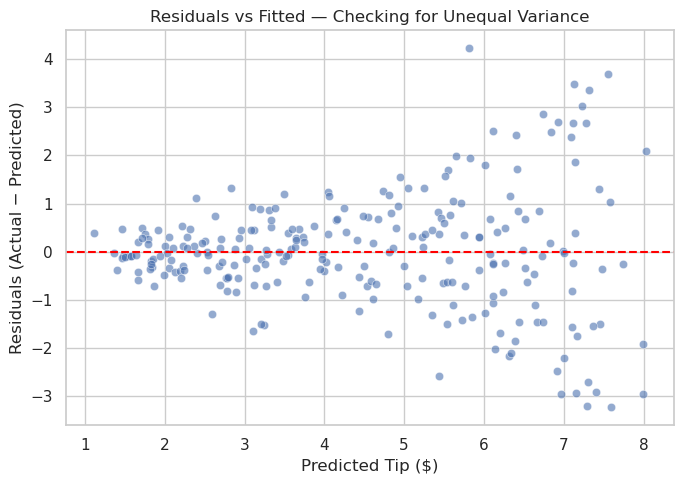

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(x=ols_model.fittedvalues, y=ols_model.resid, alpha=0.6, ax=ax)
ax.axhline(0, color="red", linestyle="--", lw=1.5)
ax.set_title("Residuals vs Fitted — Checking for Unequal Variance")
ax.set_xlabel("Predicted Tip ($)")
ax.set_ylabel("Residuals (Actual − Predicted)")
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     407.1
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           6.52e-79
Time:                        18:13:07   Log-Likelihood:                -19.666
No. Observations:                 250   AIC:                             45.33
Df Residuals:                     247   BIC:                             55.90
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1888      0.053      3.

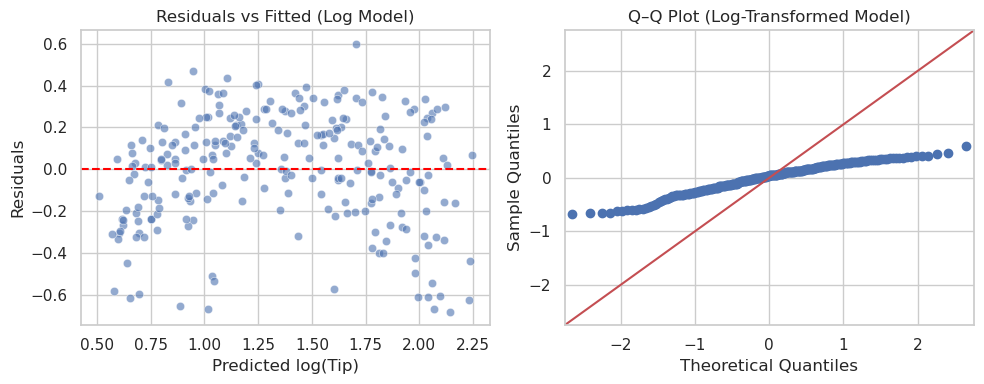

In [21]:
df["log_tip"] = np.log(df["tip_usd"] - df["tip_usd"].min() + 1)  # shift so no negatives

X_log = sm.add_constant(df[["bill_total_usd", "party_size"]])
y_log = df["log_tip"]

log_model = sm.OLS(y_log, X_log).fit()
print(log_model.summary())

# Residual plots again
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(x=log_model.fittedvalues, y=log_model.resid, alpha=0.6, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--", lw=1.5)
axes[0].set_title("Residuals vs Fitted (Log Model)")
axes[0].set_xlabel("Predicted log(Tip)")
axes[0].set_ylabel("Residuals")

sm.qqplot(log_model.resid, line="45", ax=axes[1])
axes[1].set_title("Q–Q Plot (Log-Transformed Model)")

plt.tight_layout()

try:
    from src.helpers import save_and_log_plot
    save_and_log_plot(
        plt.gcf(),
        "reports/figures/log_model_residuals_diagnostics.png",
        df=df,
        chart_type="diagnostic",
        library="matplotlib",
        x="fittedvalues",
        y="resid",
        dataset_name="tips_synthetic",
        dataset_path="data/processed/tips_synthetic.csv",
        notebook="notebooks/06_Model_Robustness_Assumption_Checks.ipynb",
        notes="Log-transformed OLS residuals diagnostic plot.",
        timestamped=True
    )
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


# --- Optional: show, then close (in this order)
plt.show()
plt.close(fig)    

| Diagnostic          | What It Tests                        | What You’re Seeing                             | Interpretation                    |
| ------------------- | ------------------------------------ | ---------------------------------------------- | --------------------------------- |
| Residuals vs Fitted | Constant variance (homoscedasticity) | Cloud of points randomly scattered around zero | Good — variance roughly constant  |
| Q–Q Plot            | Normality of residuals               | Slight tail curvature                          | Mostly normal; acceptable for OLS |


We took the logs of the tips so that bigger bills didn’t make the model’s errors blow up. Now, the leftovers (residuals) look pretty random, which is good. The line on the right says the model’s misses are close to being normally spread out — not perfect, but much cleaner.

                Model  RMSE_$     R2
0         Linear(tip)   1.192  0.713
1  Linear(log1p(tip))   1.255  0.682
✅ Saved Seaborn Axes figure to: reports/figures/compare_linear_vs_log_models_2025-11-12_1904.png
📝 Logged metadata → reports/figures/compare_linear_vs_log_models_2025-11-12_1904.json


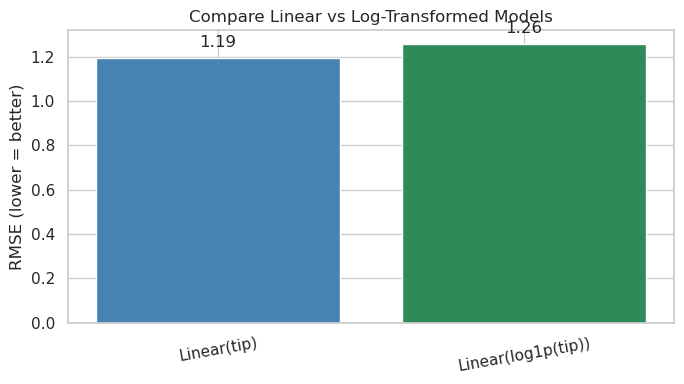

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

# --- Features & target ---
X = df[["bill_total_usd", "party_size"]].values
y = df["tip_usd"].values

# --- A) Linear model on raw tip values ---
lin = LinearRegression()
lin.fit(X, y)
y_pred_lin = lin.predict(X)

rmse_lin = mean_squared_error(y, y_pred_lin) ** 0.5   # <-- FIXED
r2_lin   = r2_score(y, y_pred_lin)

# --- B) Log-transformed model ---
y_log = np.log1p(y)
lin_log = LinearRegression()
lin_log.fit(X, y_log)
y_log_pred = lin_log.predict(X)

# Back-transform to original dollar scale
y_pred_log_back = np.expm1(y_log_pred)

rmse_log = mean_squared_error(y, y_pred_log_back) ** 0.5   # <-- FIXED
r2_log   = r2_score(y, y_pred_log_back)

# Results table
results = pd.DataFrame(
    {
        "Model": ["Linear(tip)", "Linear(log1p(tip))"],
        "RMSE_$": [rmse_lin, rmse_log],
        "R2": [r2_lin, r2_log],
    }
)

print(results.round(3))

# --- Visualization ---
fig, ax1 = plt.subplots(1, 1, figsize=(7, 4))

x = np.arange(len(results))
ax1.bar(x, results["RMSE_$"], color=["steelblue", "seagreen"])
ax1.set_ylabel("RMSE (lower = better)")
ax1.set_xticks(x)
ax1.set_xticklabels(results["Model"], rotation=10)
ax1.set_title("Compare Linear vs Log-Transformed Models")

for i, v in enumerate(results["RMSE_$"]):
    ax1.text(i, v + 0.05, f"{v:.2f}", ha="center")

plt.tight_layout()

try:
    from src.helpers import save_and_log_plot
    save_and_log_plot(
        ax1,
        "reports/figures/compare_linear_vs_log_models.png",
        df=df,
        chart_type="bar",
        library="matplotlib",
        x="Model",
        y="RMSE_$",
        dataset_name="tips_cleaned_or_synthetic",
        dataset_path="data/processed/tips_synthetic.csv",
        notebook="notebooks/06_Model_Robustness_Assumption_Checks.ipynb",
        notes="Linear vs log-transformed comparison (sklearn-old-version compatible).",
        timestamped=True,
    )
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")

plt.show()


🧸 ELI5 — Why the Linear Model Beat the Log Model

This chart compares two regression models that try to predict the tip amount in dollars:

Linear(tip) — predicts the tip directly

Linear(log1p(tip)) — predicts the log of the tip, then converts back to dollars

The bar height shows RMSE (root mean squared error) — a measure of how far off the model’s predictions are.
👉 Lower = better.

📊 What RMSE really means (kid-friendly)

RMSE answers the question:

“On average, how wrong are the model’s guesses?”

RMSE = 1.19 → model is wrong by about $1.19 on each prediction

RMSE = 1.26 → model is wrong by about $1.26

Smaller numbers = more accurate predictions.

⭐ What the chart shows
Model	RMSE	Interpretation
Linear(tip)	1.19	🎉 Better — smaller errors

Linear(log1p(tip))	1.26	Slightly worse — larger errors
✔ Plain-English Conclusion

Predicting the tip directly was more accurate than predicting the log of the tip.

Why?

The tip amounts in this dataset aren’t extremely skewed

The log transform didn’t fix anything

Converting log predictions back introduces extra noise

For these values, the simple model works best

🧸 ELI5 Analogy

Imagine guessing someone’s height.

Model A: guesses height directly

Model B: guesses the logarithm of height, then converts it back

If heights look pretty normal, guessing the log is making things unnecessarily complicated — and it performs worse.

Same thing happened with tips.

🏁 Final Takeaway

👉 If the data isn’t extremely skewed, a log transform won’t help.
👉 Sometimes the simplest model is the best model.